# Thesis Figure 1 â€” Segmentation Overlay + Adjacency Graph Zoom

Produces three publication-quality figures:
1. **Segmentation overlay** â€” image with white segment boundaries.
2. **Zoom with adjacency graph** â€” cropped region with centroid dots and adjacency edges.
3. **Overview + magnified inset** â€” full segmentation with a framed zoom box and
   dashed connecting lines to the zoomed adjacency panel.

Edit only the **Configuration** cell.

In [63]:
# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMAGE_PATH = r"REPO_ROOT/images\\images\\imagenets_0082.jpg"

OVERRIDES = [
    "segmentation=slic",  # hexagonal | slic | square
    "segmentation.n_segments=300",  # e.g. hex_radius for hexagonal
    "segmentation.compactness=20",
    "replacement=imagenet_mean",
]

# Zoom bounding box in pixels of the 224Ã—224 processed image
# (x1, y1, x2, y2)  â†’  left, top, right, bottom
ZOOM_BOX = (50, 70, 110, 130)

# Zoom-box frame + connector colour
ZOOM_BOX_COLOR = "red"

# Adjacency graph appearance
ADJ_NODE_COLOR = "yellow"
ADJ_NODE_SIZE = 6  # marker size (points)
ADJ_EDGE_COLOR = "black"
ADJ_EDGE_WIDTH = 1.5

# Set True to show segment-ID labels at centroids (useful for debugging)
SHOW_SEG_LABELS = False

OUTPUT_DIR = "output"

In [64]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from matplotlib.patches import ConnectionPatch, Rectangle


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.visualization.visualization import _segment_boundaries, _to_hwc


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  repo: {REPO_ROOT}")

device: cpu  |  repo: REPO_ROOT/n

In [65]:
# â”€â”€ Load image & build segmentation via Hydra â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(config_name="base", overrides=OVERRIDES)

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)  # [C, H, W]
input_batch = img_tensor.unsqueeze(0)  # [1, C, H, W]

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

img_np = _to_hwc(input_batch)  # [H, W, 3] float32 in [0, 1]
segs = image_graph.segments.cpu().numpy()  # [H, W] int32

print(f"Image shape : {img_np.shape}")
print(f"Segments    : {image_graph.num_segments} unique IDs")

Image shape : (224, 224, 3)
Segments    : 281 unique IDs


In [66]:
# â”€â”€ Pre-compute boundaries, zoom crop and adjacency centroids â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
boundaries = _segment_boundaries(segs)
seg_overlay = img_np.copy()
seg_overlay[boundaries] = 1.0

x1, y1, x2, y2 = ZOOM_BOX
zoom_h, zoom_w = y2 - y1, x2 - x1

zoom_img = img_np[y1:y2, x1:x2]
zoom_segs = segs[y1:y2, x1:x2]
zoom_overlay = zoom_img.copy()
zoom_overlay[_segment_boundaries(zoom_segs)] = 1.0

visible_ids = set(int(v) for v in np.unique(zoom_segs))

# Centroids of visible segments only (used for node dots)
centroids: dict[int, tuple[float, float]] = {}
for seg_id in visible_ids:
    ys_g, xs_g = np.where(segs == seg_id)
    mask = (xs_g >= x1) & (xs_g < x2) & (ys_g >= y1) & (ys_g < y2)
    if mask.sum() == 0:
        continue
    centroids[seg_id] = (
        float(xs_g[mask].mean()) - x1,
        float(ys_g[mask].mean()) - y1,
    )

# Centroids of ALL segments in zoom-local coords (can be outside the crop â€”
# matplotlib clips lines at the axes boundary, giving natural "exit" edges)
all_centroids: dict[int, tuple[float, float]] = {}
for seg_id in range(image_graph.num_segments):
    ys_g, xs_g = np.where(segs == seg_id)
    if len(xs_g) == 0:
        continue
    all_centroids[seg_id] = (float(xs_g.mean()) - x1, float(ys_g.mean()) - y1)

print(f"Zoom box : {ZOOM_BOX}  ({zoom_w}Ã—{zoom_h} px)")
print(f"Visible segments: {len(visible_ids)}  |  centroids: {len(centroids)}")

Zoom box : (50, 70, 110, 130)  (60Ã—60 px)
Visible segments: 32  |  centroids: 32


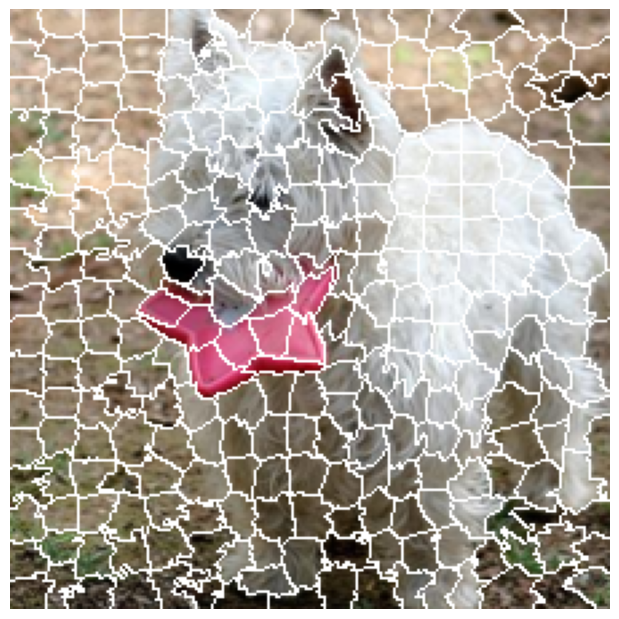

Saved â†’ output\segmentation.png


In [67]:
# â”€â”€ Figure 1: Segmentation overlay (full image) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(seg_overlay)
ax.axis("off")
fig.tight_layout(pad=0)
fig.savefig(OUT / "segmentation.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "segmentation.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'segmentation.png'}")

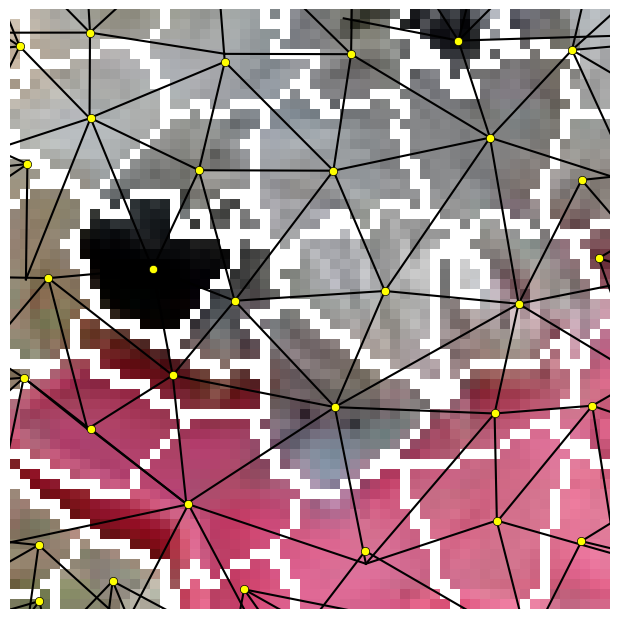

Saved â†’ output\segmentation_zoom_adj.png


In [68]:
# â”€â”€ Figure 2: Zoom crop with adjacency graph â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def _draw_adj_graph(ax):
    for seg_id in visible_ids:
        if seg_id not in centroids:
            continue
        cx1, cy1 = centroids[seg_id]
        for nb_id in image_graph.adj_list[seg_id]:
            if nb_id not in all_centroids:
                continue
            # Draw each inside-inside edge only once; inside-outside edges always
            if nb_id in visible_ids and nb_id <= seg_id:
                continue
            cx2, cy2 = all_centroids[nb_id]
            ax.plot(
                [cx1, cx2],
                [cy1, cy2],
                color=ADJ_EDGE_COLOR,
                lw=ADJ_EDGE_WIDTH,
                zorder=2,
            )
    for seg_id, (cx, cy) in centroids.items():
        ax.plot(
            cx,
            cy,
            "o",
            color=ADJ_NODE_COLOR,
            markersize=ADJ_NODE_SIZE,
            markeredgecolor="black",
            markeredgewidth=0.5,
            zorder=3,
        )
        if SHOW_SEG_LABELS:
            ax.text(
                cx,
                cy,
                str(seg_id),
                color="black",
                fontsize=6,
                ha="center",
                va="center",
                zorder=4,
            )
    # Clip outgoing edges at the zoom boundary
    ax.set_xlim(-0.5, zoom_w - 0.5)
    ax.set_ylim(zoom_h - 0.5, -0.5)


fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(zoom_overlay)
ax.axis("off")
_draw_adj_graph(ax)
fig.tight_layout(pad=0)
fig.savefig(OUT / "segmentation_zoom_adj.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "segmentation_zoom_adj.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'segmentation_zoom_adj.png'}")

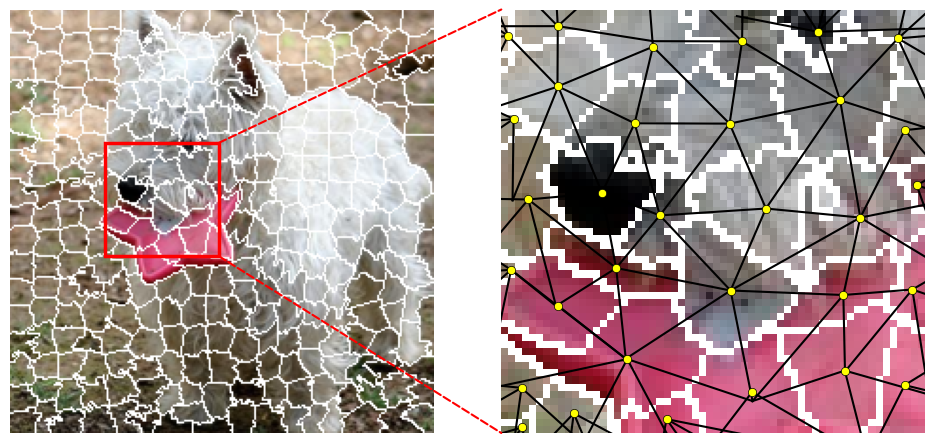

Saved â†’ output\segmentation_zoom_overview.png


In [69]:
# â”€â”€ Figure 3: Full segmentation with zoom frame + magnified adjacency panel â”€â”€â”€
#
# Layout:  [full segmentation | zoom box frame]  ----dashed lines---->  [zoomed adj graph]
#
# The two dashed connecting lines go from the right edge of the zoom box
# to the left edge of the zoomed panel, giving a classic "magnifying glass" look.

width_ratio = zoom_w / max(zoom_w, zoom_h)
fig, (ax_main, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    gridspec_kw={"width_ratios": [1, width_ratio], "wspace": 0.12},
)

# Left panel: full segmentation + zoom-box frame
ax_main.imshow(seg_overlay)
ax_main.add_patch(
    Rectangle(
        (x1, y1),
        zoom_w,
        zoom_h,
        linewidth=2.5,
        edgecolor=ZOOM_BOX_COLOR,
        facecolor="none",
        zorder=4,
    )
)
ax_main.axis("off")

# Right panel: zoomed adjacency graph
ax_zoom.imshow(zoom_overlay)
ax_zoom.axis("off")
_draw_adj_graph(ax_zoom)

# Dashed connector: top-right corner of box â†’ top-left of zoom panel
fig.add_artist(
    ConnectionPatch(
        xyA=(x2, y1),
        coordsA="data",
        axesA=ax_main,
        xyB=(-0.5, -0.5),
        coordsB="data",
        axesB=ax_zoom,
        color=ZOOM_BOX_COLOR,
        lw=1.5,
        linestyle="--",
        zorder=5,
    )
)
# Dashed connector: bottom-right corner of box â†’ bottom-left of zoom panel
fig.add_artist(
    ConnectionPatch(
        xyA=(x2, y2),
        coordsA="data",
        axesA=ax_main,
        xyB=(-0.5, zoom_h - 0.5),
        coordsB="data",
        axesB=ax_zoom,
        color=ZOOM_BOX_COLOR,
        lw=1.5,
        linestyle="--",
        zorder=5,
    )
)

fig.savefig(OUT / "segmentation_zoom_overview.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "segmentation_zoom_overview.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'segmentation_zoom_overview.png'}")